# Epsilon Fund — Strategy Testing
---

In [1]:
import pandas as pd
import numpy as np
import sys
import importlib
import matplotlib.pyplot as plt
import os


# ── Set your repo root path ────────────────────────────────────────────────────
ROOT = os.path.expanduser('~/Desktop/epsilon/github/Epsilon-Quant-Research')  # ← your Mac path
# ROOT = r'C:\Users\user\Documents\Epsilon Fund\Epsilon-Quant-Research'       # ← Dimitris Windows path (commented out)

# ──────────────────────────────────────────────────────────────────────────────


sys.path.append(os.path.join(ROOT, 'infrastructure', 'data'))
sys.path.append(os.path.join(ROOT, 'infrastructure', 'backtester'))
sys.path.append(os.path.join(ROOT, 'infrastructure', 'walkforward'))

# existing imports
from binance_client import get_binance_client
import engine
importlib.reload(engine)
from engine import backtest

# ✅ ADD THESE IMPORTS (adjust filename below)
from wf_engine import walk_forward, plateau_analysis, plateau_summary, perturbation_test, cost_stress_test

---
## Data

**Pairs** — any Binance pair in `BASEQUOTE` format (e.g. `BTCUSDT`, `ETHUSDT`, `SOLUSDT`, `BNBUSDT`).  
Verify availability at [binance.com/en/trade](https://www.binance.com/en/trade).

**Intervals** — `'1m'` `'5m'` `'15m'` `'1h'` `'4h'` `'1d'` `'1w'`

**Lookback** — days of history: `365` (1y) · `730` (2y) · `1825` (5y) · `2555` (7y, recommended minimum)

In [2]:
# =========================
# PAIR CONFIG
# =========================

Y = "SHIBUSDT"
X = "BONKUSDT"

INTERVAL = "1d"
START = "2022-01-01"

lookback = 126
z_lookback = 60
entry = 1.8
exit = 0.5
pair_cost = 0.001

client = get_binance_client()

def load_symbol_close(symbol, interval="1d", start="2022-01-01"):
    raw = client.get_historical_klines(symbol, interval, start)

    df = pd.DataFrame(
        raw,
        columns=[
            "Time", "Open", "High", "Low", "Close", "Volume",
            "Close_time", "Quote_volume", "Trades",
            "Taker_base", "Taker_quote", "Ignore"
        ]
    )

    df = df[["Time", "Open", "High", "Low", "Close", "Volume"]].copy()
    df["Time"] = pd.to_datetime(df["Time"], unit="ms")
    df["Open"] = df["Open"].astype(float)
    df["High"] = df["High"].astype(float)
    df["Low"] = df["Low"].astype(float)
    df["Close"] = df["Close"].astype(float)
    df["Volume"] = df["Volume"].astype(float)
    df = df.set_index("Time").sort_index()

    return df

df_y = load_symbol_close(Y, INTERVAL, START)
df_x = load_symbol_close(X, INTERVAL, START)

pair_prices = pd.concat(
    [
        df_y["Close"].rename(Y),
        df_x["Close"].rename(X),
    ],
    axis=1
).dropna().sort_index()

print(pair_prices.head())
print(pair_prices.tail())
print(f"Rows: {len(pair_prices)}")

            SHIBUSDT  BONKUSDT
Time                          
2023-12-15  0.000010  0.000024
2023-12-16  0.000012  0.000022
2023-12-17  0.000010  0.000023
2023-12-18  0.000010  0.000021
2023-12-19  0.000010  0.000019
            SHIBUSDT  BONKUSDT
Time                          
2026-04-03  0.000006  0.000006
2026-04-04  0.000006  0.000006
2026-04-05  0.000006  0.000006
2026-04-06  0.000006  0.000006
2026-04-07  0.000006  0.000006
Rows: 845


---
## Strategy

**Available columns:** `Open` `High` `Low` `Close` `Volume`

**Required output:** a `position` column — `1` long · `0` flat · `-1` short  
**Optional:** `position_size` column (0–1) to use fractional capital

> Signals are shifted 1 bar by the engine — no need to shift manually.

,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2024-06-16,0.427226,0.0,-0.139342,-0.130693,0.924976,-1.009636,1.0
2024-06-17,0.429554,0.0,-0.135843,-0.063211,0.909104,-1.179817,1.0
2024-06-18,0.433723,0.0,-0.129458,0.037230,0.892991,-1.350727,1.0
2024-06-19,0.434984,0.0,-0.130826,0.086418,0.876812,-1.533699,1.0
2024-06-20,0.431831,0.0,-0.142111,0.064236,0.859422,-1.719902,1.0


,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2026-04-03,0.208280,-1.0,0.041479,1.654157,0.702580,-3.625951,1.0
2026-04-04,0.209140,-1.0,0.044615,1.662895,0.699382,-3.664077,1.0
2026-04-05,0.210519,-1.0,0.050110,1.723549,0.696143,-3.704585,1.0
2026-04-06,0.205056,-1.0,0.023367,1.031796,0.692701,-3.725334,1.0
2026-04-07,0.205869,0.0,0.026715,1.081475,0.690947,-3.745550,1.0


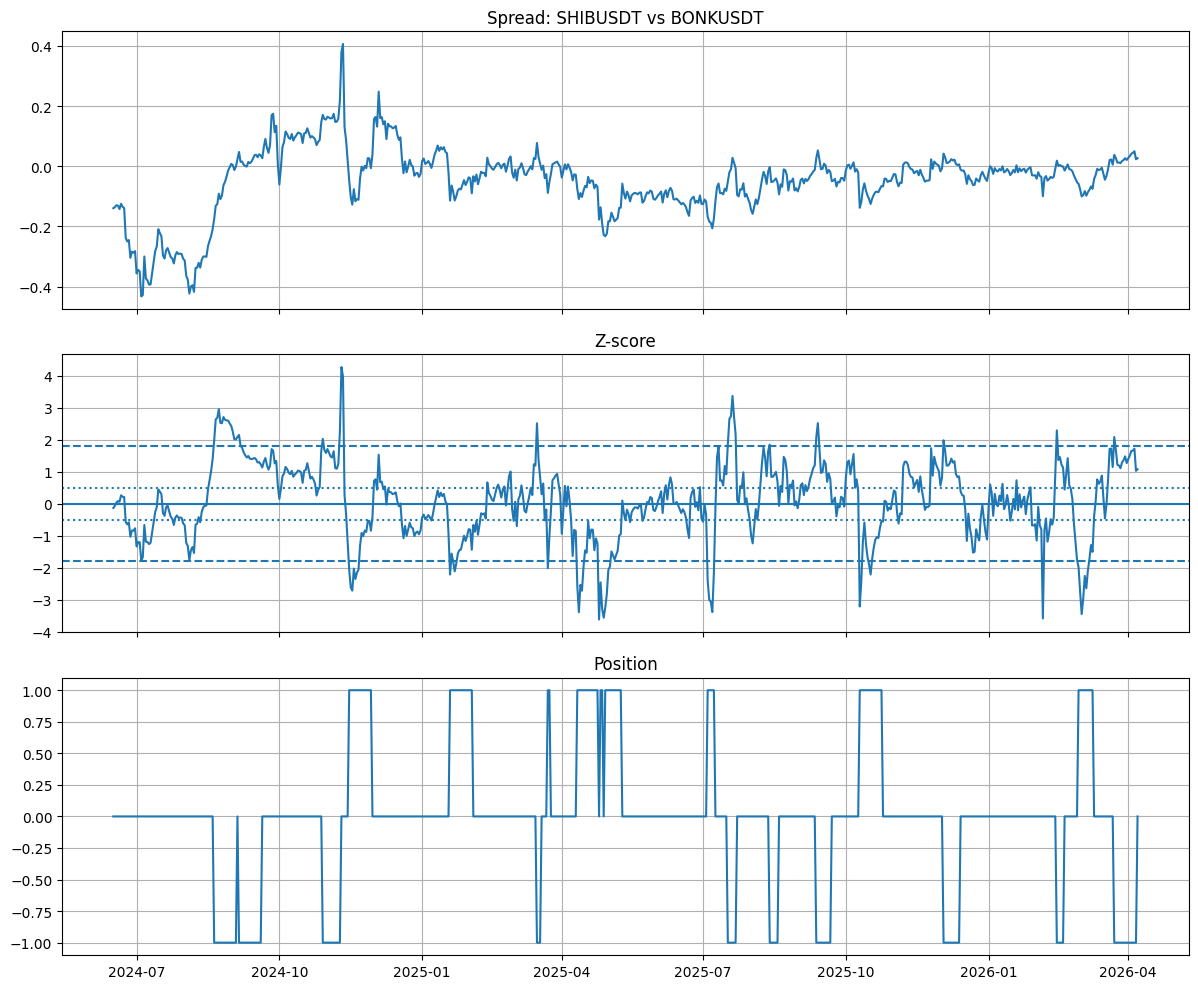

In [3]:
def build_pair_df(price_df, y_col, x_col,
                  lookback=126, z_lookback=60,
                  entry=2.0, exit=0.5,
                  stop_z=3.5, max_holding=15):

    df = price_df[[y_col, x_col]].dropna().copy()

    log_y = np.log(df[y_col])
    log_x = np.log(df[x_col])

    beta = log_y.rolling(lookback).cov(log_x) / log_x.rolling(lookback).var()
    alpha = log_y.rolling(lookback).mean() - beta * log_x.rolling(lookback).mean()

    spread = log_y - (alpha + beta * log_x)

    spread_mean = spread.rolling(z_lookback).mean()
    spread_std = spread.rolling(z_lookback).std()
    z = (spread - spread_mean) / spread_std

    raw_signal = pd.Series(np.nan, index=df.index)
    raw_signal[z > entry] = -1.0
    raw_signal[z < -entry] = 1.0
    raw_signal[z.abs() < exit] = 0.0
    raw_signal[z > stop_z] = 0.0
    raw_signal[z < -stop_z] = 0.0

    pos = pd.Series(0.0, index=df.index)

    current_pos = 0.0
    holding_days = 0

    for i in range(len(df)):
        sig = raw_signal.iloc[i]

        if current_pos == 0.0:
            if pd.notna(sig) and sig != 0.0:
                current_pos = sig
                holding_days = 1
            else:
                current_pos = 0.0
                holding_days = 0

        else:
            exit_now = False

            if pd.notna(sig) and sig == 0.0:
                exit_now = True

            if holding_days >= max_holding:
                exit_now = True

            if exit_now:
                current_pos = 0.0
                holding_days = 0
            else:
                holding_days += 1

        pos.iloc[i] = current_pos

    ret_y_log = log_y.diff()
    ret_x_log = log_x.diff()
    pair_log_ret = ret_y_log - beta.shift(1) * ret_x_log
    pair_arith_ret = np.exp(pair_log_ret) - 1.0

    out = pd.DataFrame(index=df.index)
    out["Close"] = (1.0 + pair_arith_ret.fillna(0.0)).cumprod()
    out["position"] = pos

    out["spread"] = spread
    out["z"] = z
    out["beta"] = beta.shift(1)
    out["alpha"] = alpha
    out["position_size"] = 1.0

    out = out.dropna(subset=["Close", "position", "spread", "z", "beta"])

    return out

def pair_strategy_fn(df_slice, params):
    lookback = int(params["lookback"])
    z_lookback = int(params["z_lookback"])
    entry = float(params["entry"])
    exit = float(params["exit"])
    stop_z = float(params["stop_z"])
    max_holding = int(params["max_holding"])

    if exit >= entry:
        return None

    if stop_z <= entry:
        return None

    if max_holding <= 0:
        return None

    if len(df_slice) < lookback + z_lookback + 20:
        return None

    strategy_df = build_pair_df(
        price_df=df_slice,
        y_col=Y,
        x_col=X,
        lookback=lookback,
        z_lookback=z_lookback,
        entry=entry,
        exit=exit,
        stop_z=stop_z,
        max_holding=max_holding,
    )

    if strategy_df is None or len(strategy_df) == 0:
        return None

    indicator_cols = ["spread", "z", "beta"]
    return strategy_df, indicator_cols

pair_df = build_pair_df(
    price_df=pair_prices,
    y_col=Y,
    x_col=X,
    lookback=lookback,
    z_lookback=z_lookback,
    entry=entry,
    exit=exit
)

display(pair_df.head())
display(pair_df.tail())

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(pair_df.index, pair_df["spread"])
axes[0].set_title(f"Spread: {Y} vs {X}")
axes[0].grid(True)

axes[1].plot(pair_df.index, pair_df["z"])
axes[1].axhline(entry, linestyle="--")
axes[1].axhline(-entry, linestyle="--")
axes[1].axhline(exit, linestyle=":")
axes[1].axhline(-exit, linestyle=":")
axes[1].axhline(0, linestyle="-")
axes[1].set_title("Z-score")
axes[1].grid(True)

axes[2].plot(pair_df.index, pair_df["position"])
axes[2].set_title("Position")
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [4]:
param_defs = {
    "lookback":    ("int",   90, 110),
    "z_lookback":  ("int",   60, 100),
    "entry":       ("float", 1, 3),
    "exit":        ("float", 0.5, 1.00),
    "stop_z":      ("float", 3.5, 5.00),
    "max_holding": ("int",   8,   25),
}

fixed_params = {"exit": 0.6325, "stop_z": 4.4069
}   

def pair_reject(metrics):
    if metrics is None:
        return True
    if metrics["num_trades"] < 5:
        return True
    if metrics["profit_factor"] < 0.7:
        return True
    return False

test_params = {
    "lookback": 126,
    "z_lookback": 60,
    "entry": 1.8,
    "exit": 0.5,
    "stop_z": 3.5,
    "max_holding": 15,
}

pair_df, indicator_cols = pair_strategy_fn(pair_prices.copy(), test_params)

display(pair_df.head())
display(pair_df.tail())

results = backtest(
    data=pair_df,
    cost=pair_cost,
    show_plot=True,
    save_html=None,
    show_trades=False,
    benchmark_data=None
)

print(f"Pair: {Y} vs {X}")
print(f"Return        {results['total_return']*100:>8.2f}%")
print(f"Sharpe        {results['sharpe_ratio']:>8.2f}")
print(f"Max Drawdown  {results['max_drawdown']*100:>8.2f}%")
print(f"Calmar        {results['calmar_ratio']:>8.2f}")
print(f"Trades        {results['num_trades']:>8}")
print(f"Win Rate      {results['win_rate']*100:>8.2f}%")
print(f"Profit Factor {results['profit_factor']:>8.2f}")



,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2024-06-16,0.427226,0.0,-0.139342,-0.130693,0.924976,-1.009636,1.0
2024-06-17,0.429554,0.0,-0.135843,-0.063211,0.909104,-1.179817,1.0
2024-06-18,0.433723,0.0,-0.129458,0.037230,0.892991,-1.350727,1.0
2024-06-19,0.434984,0.0,-0.130826,0.086418,0.876812,-1.533699,1.0
2024-06-20,0.431831,0.0,-0.142111,0.064236,0.859422,-1.719902,1.0


,Close,position,spread,z,beta,alpha,position_size
Time,,,,,,,
2026-04-03,0.208280,-1.0,0.041479,1.654157,0.702580,-3.625951,1.0
2026-04-04,0.209140,-1.0,0.044615,1.662895,0.699382,-3.664077,1.0
2026-04-05,0.210519,-1.0,0.050110,1.723549,0.696143,-3.704585,1.0
2026-04-06,0.205056,-1.0,0.023367,1.031796,0.692701,-3.725334,1.0
2026-04-07,0.205869,0.0,0.026715,1.081475,0.690947,-3.745550,1.0


Pair: SHIBUSDT vs BONKUSDT
Return           18.37%
Sharpe            0.47
Max Drawdown    -38.11%
Calmar            0.26
Trades              19
Win Rate         73.68%
Profit Factor     1.46


In [5]:
wf_results = walk_forward(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    param_defs=param_defs,
    fixed_params=fixed_params,
    train_bars=400,
    test_bars=85,
    burnin_bars=200,
    n_trials=400,
    cost=pair_cost,
    reject_fn=pair_reject,
    save_csv=None,
)

results_df = wf_results["results_df"]
all_best_params = wf_results["all_best_params"]
consensus_params = wf_results["consensus_params"]
stability_df = wf_results["stability_df"]
oos_combined_df = wf_results["oos_combined_df"]
oos_metrics = wf_results["oos_metrics"]

display(results_df)
print("Consensus params:", consensus_params)
display(stability_df)
print("OOS metrics:", oos_metrics)

sweep_results = plateau_analysis(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    base_params=wf_results["consensus_params"],
    param_defs=param_defs,
    fixed_params=fixed_params,
    cost=pair_cost,
    reject_fn=pair_reject,
    n_steps=20,
)

plateau_df = plateau_summary(
    sweep_results=sweep_results,
    base_params=wf_results["consensus_params"],
    stability_df=wf_results["stability_df"],
    threshold=0.20,
)

display(plateau_df)  

perturb_df = perturbation_test(
    df=pair_prices,
    strategy_fn=pair_strategy_fn,
    base_params=wf_results["consensus_params"],
    param_defs=param_defs,
    fixed_params=fixed_params,
    cost=pair_cost,
    reject_fn=pair_reject,
    pct_offsets=(0.05, 0.10, 0.20),
    n_samples=50,
    seed=42,
)

display(perturb_df)

cost_df = cost_stress_test(
    oos_combined_df=wf_results["oos_combined_df"],
    cost_multipliers=(1.0, 1.5, 2.0, 3.0),
    base_cost=pair_cost,
)

display(cost_df)



UPDATED WALK_FORWARD FILE IS RUNNING
Walk-forward: 5 fold(s)  train=400  test=85  burnin=200  trials=400
  Fold 1: train 2023-12-15 → 2025-01-17  | test 2025-01-18 → 2025-04-12
  Fold 2: train 2024-03-09 → 2025-04-12  | test 2025-04-13 → 2025-07-06
  Fold 3: train 2024-06-02 → 2025-07-06  | test 2025-07-07 → 2025-09-29
  Fold 4: train 2024-08-26 → 2025-09-29  | test 2025-09-30 → 2025-12-23
  Fold 5: train 2024-11-19 → 2025-12-23  | test 2025-12-24 → 2026-03-18

Fixed (2): ['exit', 'stop_z']
Free  (4): ['lookback', 'z_lookback', 'entry', 'max_holding']

────────────────────────────────────────────────────────────
Fold 1/5  train: 2023-12-15 → 2025-01-17  test: 2025-01-18 → 2025-04-12


  0%|          | 0/400 [00:00<?, ?it/s]

test_m: {'total_return': np.float64(0.09291684931118627), 'sharpe_ratio': np.float64(3.0149921672323066), 'max_drawdown': np.float64(-0.0010000000000000009), 'win_rate': 1.0, 'num_trades': 1, 'avg_win_loss_ratio': 0.0, 'profit_factor': inf, 'calmar_ratio': np.float64(370.06373285537677), 'yearly_returns': {2024: np.float64(0.0), 2025: np.float64(0.09291684931118627)}, 'yearly_sharpe': {2024: 0.0, 2025: np.float64(3.0149921672323066)}, 'yearly_max_drawdown': {2024: np.float64(0.0), 2025: np.float64(-0.0010000000000000009)}, 'cost_percent': 0.001, 'equity_curve': Time
2024-12-31    1.000000
2025-01-01    1.000000
2025-01-02    1.000000
2025-01-03    1.000000
2025-01-04    1.000000
                ...   
2025-04-08    1.092917
2025-04-09    1.092917
2025-04-10    1.092917
2025-04-11    1.092917
2025-04-12    1.092917
Freq: D, Name: net_returns, Length: 103, dtype: float64, 'trades':   entry_time  exit_time  entry_price  exit_price direction       pnl
0 2025-03-16 2025-03-19     0.795935  

  0%|          | 0/400 [00:00<?, ?it/s]

test_m: {'total_return': np.float64(0.07940877216881637), 'sharpe_ratio': np.float64(1.3637343185095296), 'max_drawdown': np.float64(-0.09534050043714914), 'win_rate': 0.6666666666666666, 'num_trades': 3, 'avg_win_loss_ratio': np.float64(3.3111702609848117), 'profit_factor': np.float64(6.622340521969623), 'calmar_ratio': np.float64(3.191187802799782), 'yearly_returns': {2025: np.float64(0.07940877216881637)}, 'yearly_sharpe': {2025: np.float64(1.3637343185095296)}, 'yearly_max_drawdown': {2025: np.float64(-0.09534050043714914)}, 'cost_percent': 0.001, 'equity_curve': Time
2025-03-24    1.000000
2025-03-25    1.000000
2025-03-26    1.000000
2025-03-27    1.000000
2025-03-28    1.000000
                ...   
2025-07-02    1.104702
2025-07-03    1.104702
2025-07-04    1.104702
2025-07-05    1.103598
2025-07-06    1.079409
Freq: D, Name: net_returns, Length: 105, dtype: float64, 'trades':   entry_time  exit_time  entry_price  exit_price direction       pnl
0 2025-04-12 2025-04-18     0.85

...

,param,plateau_pct,cv_fold,verdict
0,lookback,95.000000,0.046869,Robust
1,z_lookback,85.000000,0.105596,Robust
2,entry,40.000000,0.183728,Moderate
3,max_holding,38.888889,0.634350,Moderate



═══════════════════════════════════════════════════════════════════════════
PERTURBATION TEST — NEIGHBOURHOOD ROBUSTNESS
═══════════════════════════════════════════════════════════════════════════
Base score: 0.6568
  Offset  N valid     Mean   Median      Std      Min  Degradation
──────── ──────── ──────── ──────── ──────── ──────── ────────────
      5%       50   0.6392   0.6387   0.0294   0.5732        2.7%
     10%       50   0.6224   0.6176   0.0487   0.4996        5.2%
     20%       50   0.5414   0.5270   0.0770   0.3852       17.6%


,offset_pct,n_valid,mean_score,median_score,std_score,min_score,degradation
0,0.05,50,0.639220,0.638711,0.029353,0.573244,0.026746
1,0.10,50,0.622411,0.617565,0.048746,0.499647,0.052338
2,0.20,50,0.541377,0.526954,0.076976,0.385236,0.175718



═══════════════════════════════════════════════════════════════════════════
TRANSACTION COST STRESS TEST
═══════════════════════════════════════════════════════════════════════════
    Cost   Mult   Sharpe     Return      MaxDD   Calmar       PF
──────── ────── ──────── ────────── ────────── ──────── ────────
  0.0010   1.0x     2.93    120.41%     -9.53%     9.63    22.49
  0.0015   1.5x     2.87    116.93%     -9.53%     9.36    22.49
  0.0020   2.0x     2.82    113.51%     -9.53%     9.11    22.49
  0.0030   3.0x     2.71    106.82%     -9.53%     8.60    22.49


,cost,cost_mult,sharpe,total_return,max_drawdown,calmar,profit_factor,num_trades
0,0.0010,1.0,2.926385,1.204051,-0.095341,9.625927,22.49169,16
1,0.0015,1.5,2.873285,1.169309,-0.095341,9.364320,22.49169,16
2,0.0020,2.0,2.819726,1.135097,-0.095341,9.105988,22.49169,16
3,0.0030,3.0,2.711292,1.068234,-0.095341,8.598992,22.49169,16


---
## Backtest

| Parameter | Options | Default |
|---|---|---|
| `cost` | Cost per trade as decimal — `0.001` = 0.1% | `0.0` |
| `show_plot` | `True` / `False` | `True` |
| `save_html` | Filename string or `None` | `None` |
| `show_trades` | Overlay entry/exit markers on price chart | `False` |
| `benchmark_data` | DataFrame with `Close` column for buy & hold comparison | same asset |

In [ ]:
from wf_visualizer import plot_walk_forward_results

plot_walk_forward_results(
    results        = wf_results,
    param_defs     = param_defs,
    fixed_params   = fixed_params,
    benchmark_data = None,       # pair strategies have no single B&H benchmark
    show           = True,
    save_html_dir  = None,
    show_fold_perf = False,
    show_param_evol= False,
    show_oos_equity= True,
    show_trades    = False,
)


In [7]:
wf_results['oos_combined_df'].to_pickle('shib_bonk_oos.pkl')
print('Saved shib_bonk_oos.pkl')


Saved shib_bonk_oos.pkl
